In [ ]:
import ipywidgets as widgets
from IPython.display import display
import glob
import os
import os
# Get all image files in the current directory
image_files = glob.glob("*.jpg") + glob.glob("*.jpeg") + glob.glob("*.png")
image_files.sort()

# Create a dropdown widget
file_dropdown = widgets.Dropdown(
    options=image_files,
    value=image_files[0] if image_files else None,
    description='Image File:',
    disabled=False,
    layout={'width': 'max-content'}
)

grid_rows = 8
grid_cols = 8

display(file_dropdown)


Dropdown(description='Image File:', layout=Layout(width='max-content'), options=('25 uM FL 200uM P5 A.jpg', '2…

Processing file: 25 uM SCR073  200uM P2 C.jpg


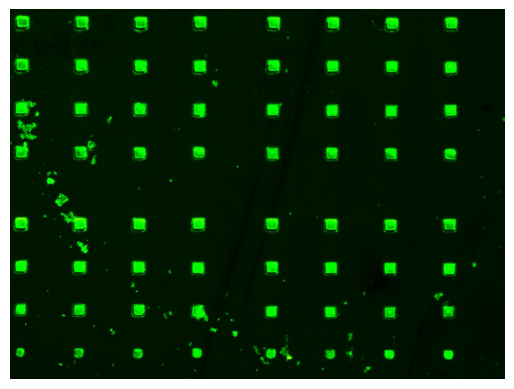

In [558]:
import cv2
import matplotlib.pyplot as plt

# Load image in BGR (OpenCV default)
filename = file_dropdown.value
print(f"Processing file: {filename}")
img_bgr = cv2.imread(filename)

# Convert BGR to RGB for Matplotlib
if img_bgr is None:
    print('Error: Could not load image. Please check the file path.')
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the image
    plt.imshow(img_rgb)
    plt.axis('off')  # Optional: hide axis ticks


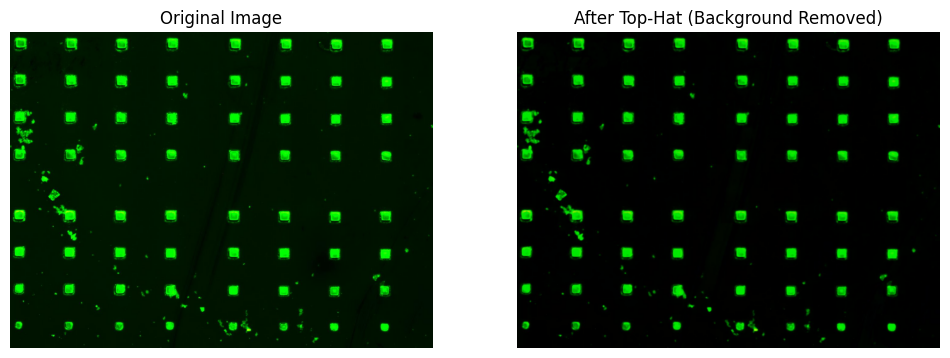

In [559]:
# Apply a median filter to the original image to reduce noise
img_median = cv2.medianBlur(img_rgb, 5)

# Define a structuring element for the Top-Hat transform
# IMPORTANT: The kernel size (here 51x51) MUST be larger than the squares you want to keep!
# Adjust the size accordingly if the squares are larger or smaller in your image.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (51, 51))

# Apply White Top-Hat transform
# This extracts bright objects on a dark background, effectively removing uneven illumination.
# (If your squares are dark on a bright background, use cv2.MORPH_BLACKHAT instead)
img_tophat = cv2.morphologyEx(img_median, cv2.MORPH_TOPHAT, kernel)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_tophat)
plt.title("After Top-Hat (Background Removed)")
plt.axis("off")
plt.show()


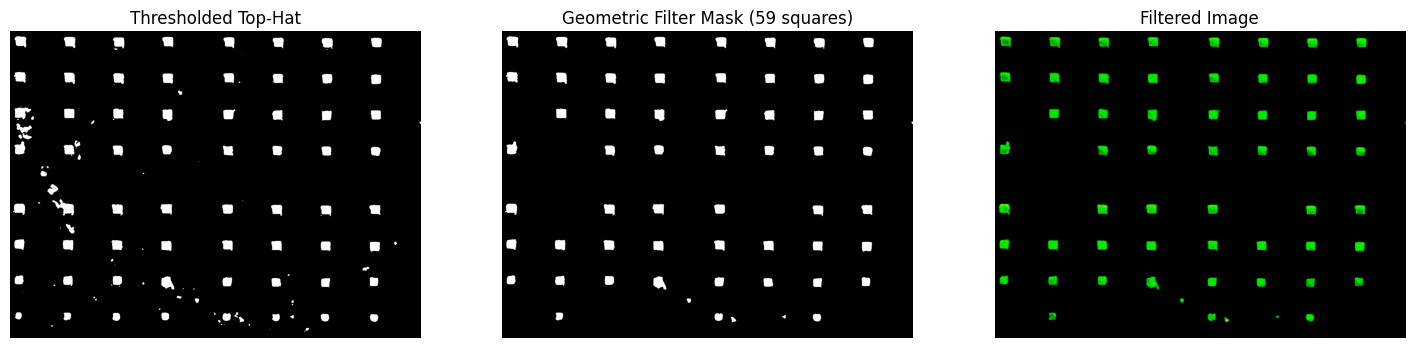

In [560]:
import numpy as np

# Convert to grayscale for thresholding and contour detection
gray_tophat = cv2.cvtColor(img_tophat, cv2.COLOR_RGB2GRAY)

# Threshold to isolate the bright features
_, binary_tophat = cv2.threshold(gray_tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(binary_tophat, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
for cnt in contours:
    # Approximate contour with a polygon
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)
    
    # We are looking for square-like features, so we want polygons with 4 vertices
    if len(approx) == 4:
        # Check if the polygon is convex
        if cv2.isContourConvex(approx):
            # Compute bounding rectangle to check aspect ratio (width / height)
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = float(w) / h
            
            # A square will have an aspect ratio close to 1.0
            if 0.5 <= aspect_ratio <= 2.0:
                # Optional: filter by area to remove tiny noise or huge contours
                area = cv2.contourArea(cnt)
                if area > 10:  # Adjust this threshold based on actual square sizes
                    filtered_contours.append(cnt)

# Create an empty mask to draw the filtered square contours
mask = np.zeros_like(gray_tophat)
cv2.drawContours(mask, filtered_contours, -1, 255, thickness=cv2.FILLED)

# Filter out everything else using the mask on the tophat image
img_filtered = cv2.bitwise_and(img_tophat, img_tophat, mask=mask)

# Display the results
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(binary_tophat, cmap="gray")
plt.title("Thresholded Top-Hat")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(f"Geometric Filter Mask ({len(filtered_contours)} squares)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_filtered)
plt.title("Filtered Image")
plt.axis("off")
plt.show()

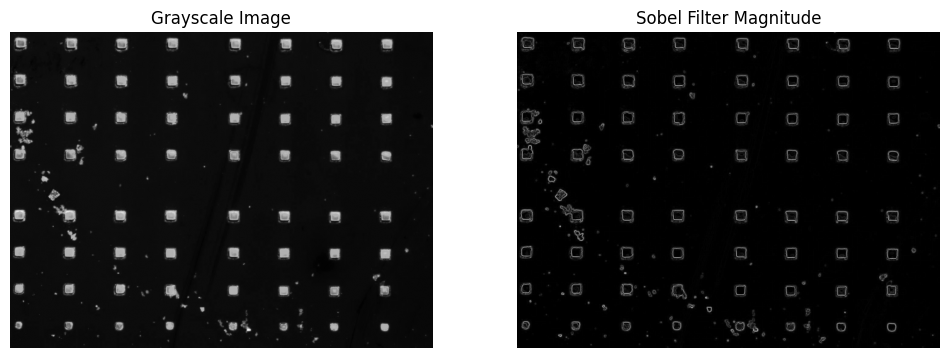

In [561]:
# Convert original image to grayscale for Sobel edge detection
gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply Sobel filter in X and Y directions
sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# Calculate the gradient magnitude
sobel_magnitude = cv2.magnitude(sobelx, sobely)

# Normalize the magnitude to 0-255 for display
sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Display the result
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(gray_img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_magnitude, cmap="gray")
plt.title("Sobel Filter Magnitude")
plt.axis("off")
plt.show()


(np.float64(-0.5), np.float64(1391.5), np.float64(1039.5), np.float64(-0.5))

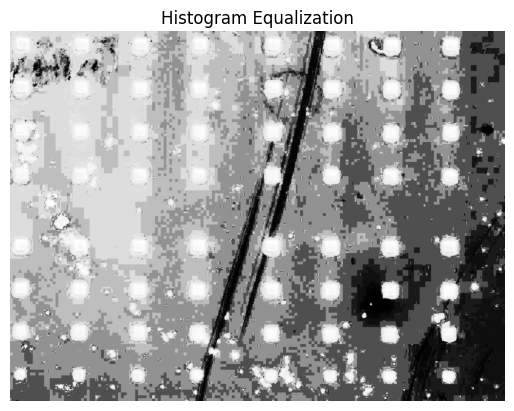

In [562]:
# Convert to HSV color space to perform histogram equalization on the Value channel
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Equalize the V channel
img_hsv[:, :] = cv2.equalizeHist(img_hsv[:, :])

# Display the equalized image
plt.imshow(img_hsv, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

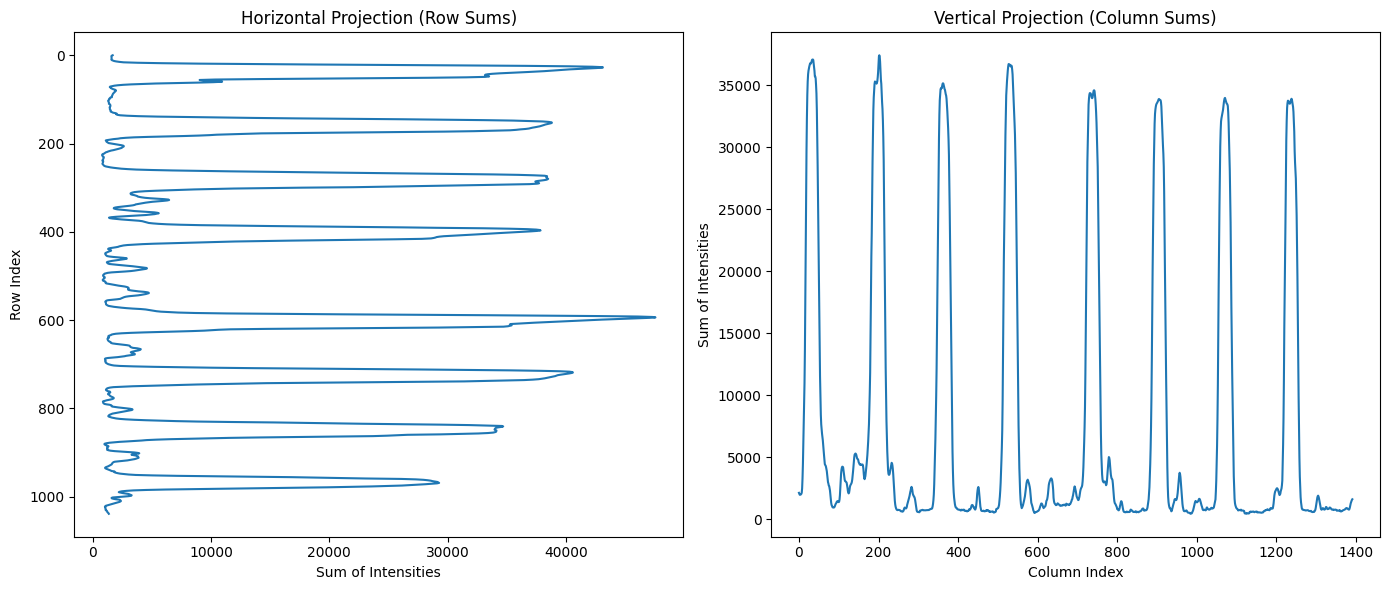

In [563]:
# Create 1D horizontal and vertical projection map
# Accumulating pixel intensities by column (vertical projection) and row (horizontal projection)
# We will use gray_tophat which is the grayscale top hat image from the previous cell

horizontal_projection = np.sum(gray_tophat, axis=1)
vertical_projection = np.sum(gray_tophat, axis=0)

plt.figure(figsize=(14, 6))

# Visualize horizontal projection
plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)))
plt.gca().invert_yaxis() # Invert y-axis to match image orientation
plt.title('Horizontal Projection (Row Sums)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')

# Visualize vertical projection
plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection)
plt.title('Vertical Projection (Column Sums)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')

plt.tight_layout()
plt.show()


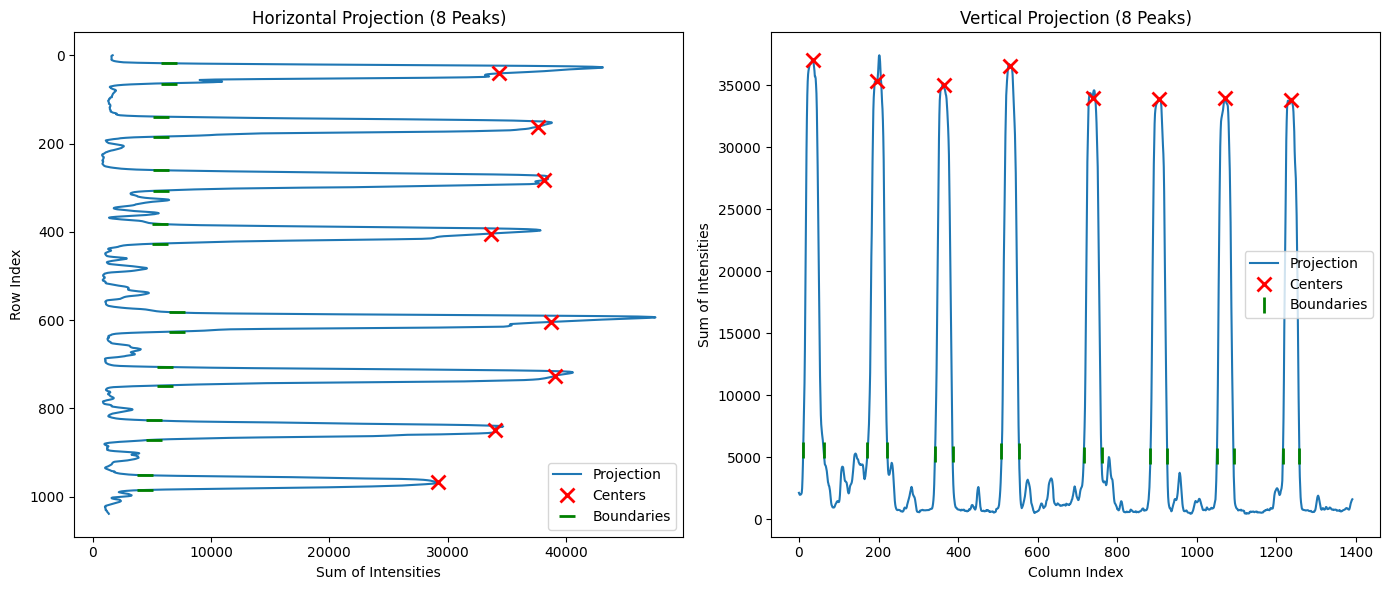

Horizontal grid row positions: [ 41 162 283 404 604 727 849 968]
Vertical grid column positions: [  36  197  364  531  738  904 1071 1237]


In [564]:
from scipy.signal import find_peaks

# Function to extract the top N peaks and calculate their centers from their boundaries
def get_top_n_peaks(projection, n, min_dist=30):
    # Find all peaks and their prominences
    peaks, properties = find_peaks(projection, prominence=np.max(projection)*0.015)
    prominences = properties["prominences"]
    
    # Greedily select top N peaks that are at least min_dist apart (Non-Maximum Suppression)
    sort_indices = np.argsort(prominences)[::-1]
    selected_peaks = []
    for idx in sort_indices:
        p = peaks[idx]
        too_close = False
        for sp in selected_peaks:
            if abs(p - sp) < min_dist:
                too_close = True
                break
        if not too_close:
            selected_peaks.append(p)
            if len(selected_peaks) == n:
                break
                
    # Sort peaks geometrically
    selected_peaks = np.sort(selected_peaks)
    
    # Find the lower boundaries for each peak and compute the midpoint center
    centers = []
    left_boundaries = []
    right_boundaries = []
    thresholds = []
    threshold_ratio = 0.15
    for idx, p in enumerate(selected_peaks):
        val = projection[p]
        thresh = val * threshold_ratio
        
        # Safety limits: do not cross the midpoint with adjacent peaks to prevent overlaps
        min_left = 0
        if idx > 0:
            min_left = (selected_peaks[idx-1] + p) // 2
            
        max_right = len(projection) - 1
        if idx < len(selected_peaks) - 1:
            max_right = (p + selected_peaks[idx+1]) // 2
            
        # Go left from the peak index to the boundary
        left = p
        while left > min_left and projection[left] > thresh:
            left -= 1
            
        # Go right from the peak index to the boundary
        right = p
        while right < max_right and projection[right] > thresh:
            right += 1
            
        # Center is the midpoint of these lower boundaries
        center = int((left + right) / 2)
        centers.append(center)
        left_boundaries.append(left)
        right_boundaries.append(right)
        thresholds.append(thresh)
        
    return np.array(centers), np.array(left_boundaries), np.array(right_boundaries), np.array(thresholds)

# Find 8 local peaks and their boundaries for both axes
horizontal_peaks, horizontal_left, horizontal_right, horizontal_thresholds = get_top_n_peaks(horizontal_projection, grid_rows)
vertical_peaks, vertical_left, vertical_right, vertical_thresholds = get_top_n_peaks(vertical_projection, grid_cols)

# Visualize the peaks and boundaries on the projections
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(horizontal_projection, range(len(horizontal_projection)), label="Projection")
plt.plot(horizontal_projection[horizontal_peaks], horizontal_peaks, "rx", markersize=10, markeredgewidth=2, label="Centers") # Mark centers with Red X
plt.plot(horizontal_thresholds, horizontal_left, "g_", markersize=12, markeredgewidth=2, label="Boundaries") # Mark boundaries with Green horizontal ticks level at threshold
plt.plot(horizontal_thresholds, horizontal_right, "g_", markersize=12, markeredgewidth=2)
plt.gca().invert_yaxis()
plt.title(f'Horizontal Projection ({len(horizontal_peaks)} Peaks)')
plt.xlabel('Sum of Intensities')
plt.ylabel('Row Index')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(vertical_projection)), vertical_projection, label="Projection")
plt.plot(vertical_peaks, vertical_projection[vertical_peaks], "rx", markersize=10, markeredgewidth=2, label="Centers") # Mark centers with Red X
plt.plot(vertical_left, vertical_thresholds, "g|", markersize=12, markeredgewidth=2, label="Boundaries") # Mark boundaries with Green vertical ticks level at threshold
plt.plot(vertical_right, vertical_thresholds, "g|", markersize=12, markeredgewidth=2)
plt.title(f'Vertical Projection ({len(vertical_peaks)} Peaks)')
plt.xlabel('Column Index')
plt.ylabel('Sum of Intensities')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Horizontal grid row positions: {horizontal_peaks}")
print(f"Vertical grid column positions: {vertical_peaks}")


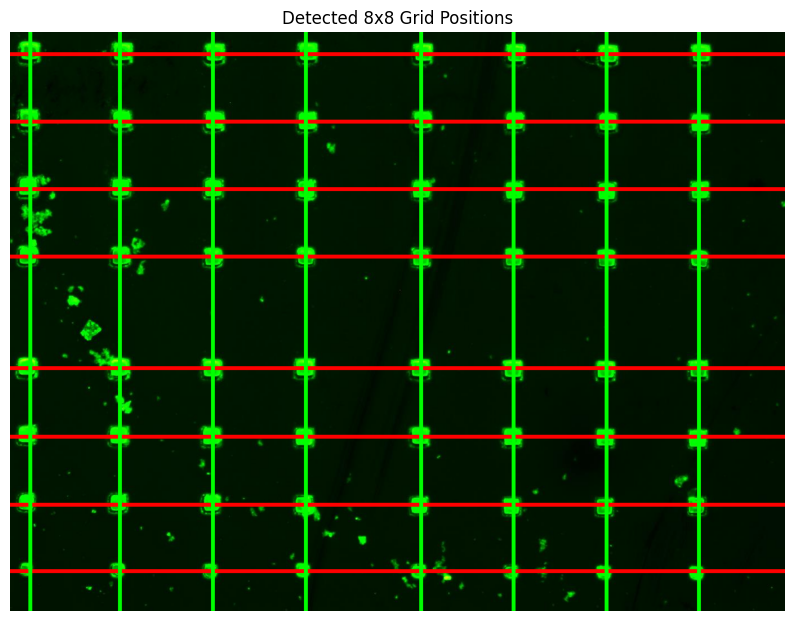

In [565]:
# Create a copy of the original RGB image to draw the grid lines
img_grid = img_rgb.copy()

# Draw horizontal grid lines (rows) based on detected peaks
for row_idx in horizontal_peaks:
    # OpenCV uses (x, y) coordinates, so row index is y
    cv2.line(img_grid, (0, row_idx), (img_grid.shape[1], row_idx), (255, 0, 0), thickness=5) # Red lines for rows

# Draw vertical grid lines (columns) based on detected peaks
for col_idx in vertical_peaks:
    # column index is x
    cv2.line(img_grid, (col_idx, 0), (col_idx, img_grid.shape[0]), (0, 255, 0), thickness=5) # Green lines for columns

# Display the original image with the overlayed grid
plt.figure(figsize=(10, 10))
plt.imshow(img_grid)
plt.title("Detected 8x8 Grid Positions")
plt.axis("off")
plt.show()


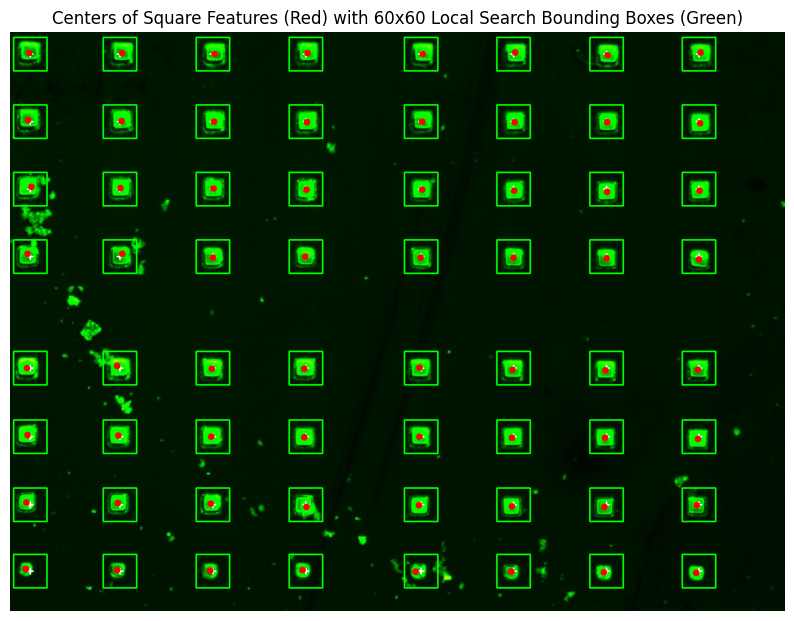

Total features detected: 64 (Grid: 8x8)
Top-left feature center (x, y): (np.int64(34), np.int64(39))


In [ ]:
# Calculate the center of each square-shaped feature
# The centers are located at the intersections of the horizontal and vertical projection peaks,
# and refined locally in a 60x60 area around each centroid
feature_centers = []
for r_idx, row_idx in enumerate(horizontal_peaks):
    row_centers = []
    for c_idx, col_idx in enumerate(vertical_peaks):
        # Initial global intersection coordinates
        cx, cy = col_idx, row_idx
        
        # Local 60x60 region bounding box centered at (cx, cy)
        x_min = max(0, cx - 30)
        x_max = min(gray_tophat.shape[1], cx + 30)
        y_min = max(0, cy - 30)
        y_max = min(gray_tophat.shape[0], cy + 30)
        
        local_region = gray_tophat[y_min:y_max, x_min:x_max]
        
        # Refine Y (Row Index) using local horizontal projection (summing across rows, i.e., axis=1)
        local_horizontal = np.sum(local_region, axis=1)
        if len(local_horizontal) > 0:
            p_y = np.argmax(local_horizontal)
            val_y = local_horizontal[p_y]
            thresh_y = val_y * 0.15
            
            left_y = p_y
            while left_y > 0 and local_horizontal[left_y] > thresh_y:
                left_y -= 1
            right_y = p_y
            while right_y < len(local_horizontal) - 1 and local_horizontal[right_y] > thresh_y:
                right_y += 1
            refined_cy = y_min + (left_y + right_y) // 2
        else:
            refined_cy = cy
            
        # Refine X (Column Index) using local vertical projection (summing across columns, i.e., axis=0)
        local_vertical = np.sum(local_region, axis=0)
        if len(local_vertical) > 0:
            p_x = np.argmax(local_vertical)
            val_x = local_vertical[p_x]
            thresh_x = val_x * 0.15
            
            left_x = p_x
            while left_x > 0 and local_vertical[left_x] > thresh_x:
                left_x -= 1
            right_x = p_x
            while right_x < len(local_vertical) - 1 and local_vertical[right_x] > thresh_x:
                right_x += 1
            refined_cx = x_min + (left_x + right_x) // 2
        else:
            refined_cx = cx
            
        row_centers.append((refined_cx, refined_cy))
    feature_centers.append(row_centers)

# Visualize the centers and the local refinement bounding boxes on the original image
img_centers = img_rgb.copy()
for r_idx, row_idx in enumerate(horizontal_peaks):
    for c_idx, col_idx in enumerate(vertical_peaks):
        cx, cy = col_idx, row_idx
        refined_cx, refined_cy = feature_centers[r_idx][c_idx]
        
        # Bounds for the local 60x60 search area
        x_min = max(0, cx - 30)
        x_max = min(img_centers.shape[1], cx + 30)
        y_min = max(0, cy - 30)
        y_max = min(img_centers.shape[0], cy + 30)
        
        # Draw the 60x60 local refinement bounding box (Green)
        cv2.rectangle(img_centers, (x_min, y_min), (x_max, y_max), color=(0, 255, 0), thickness=2)
        
        # Draw initial global intersection center (Blue marker)
        cv2.drawMarker(img_centers, (cx, cy), color=(155, 0, 255), markerType=cv2.MARKER_CROSS, markerSize=10, thickness=2)
        
        # Draw refined local center (Red circle)
        cv2.circle(img_centers, (refined_cx, refined_cy), radius=6, color=(255, 0, 0), thickness=-1)

plt.figure(figsize=(10, 10))
plt.imshow(img_centers)
plt.title("Centers of Square Features (Red) with 60x60 Local Search Bounding Boxes (Green)")
plt.axis("off")
plt.show()

# Example output
print(f"Total features detected: {len(feature_centers) * len(feature_centers[0])} (Grid: {len(feature_centers)}x{len(feature_centers[0])})")
print(f"Top-left feature center (x, y): {feature_centers[0][0]}")


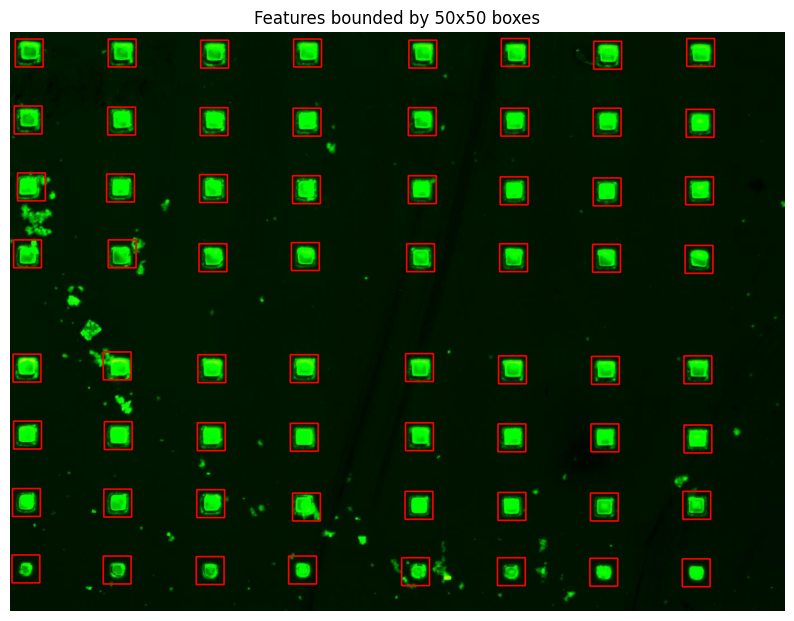

In [567]:
# Define a fixed box size based on the square features (e.g., 15x15 pixels)
box_width = 50
box_height = 50

img_boxes = img_rgb.copy()
hw = box_width // 2
hh = box_height // 2

for row in feature_centers:
    for cx, cy in row:
        # Compute top-left and bottom-right corner of the bounding box
        # Ensure we don't go out of image bounds
        top_left = (max(0, cx - hw), max(0, cy - hh))
        bottom_right = (min(img_boxes.shape[1], cx + hw), min(img_boxes.shape[0], cy + hh))
        
        # Draw the green rectangle
        cv2.rectangle(img_boxes, top_left, bottom_right, (255, 0, 0), thickness=2)
        
# Display the result
plt.figure(figsize=(10, 10))
plt.imshow(img_boxes)
plt.title(f"Features bounded by {box_width}x{box_height} boxes")
plt.axis("off")
plt.show()


In [568]:
import pandas as pd
import numpy as np
import os

# Reorder the features into 4 quadrants (groups of 16 data points) 
# to match exactly the ordering from profilometryheights_notebook.ipynb
quadrant_ranges = [
    ((0, 4), (0, 4)), # Bottom-Left (min x, min y)
    ((0, 4), (4, 8)), # Top-Left (min x, max y)
    ((4, 8), (0, 4)), # Bottom-Right (max x, min y)
    ((4, 8), (4, 8))  # Top-Right (max x, max y)
]

ordered_centers = []
for col_range, row_range in quadrant_ranges:
    for r in sorted(range(row_range[0], row_range[1]), reverse=True):
        for c in sorted(range(col_range[0], col_range[1]), reverse=True):
            ordered_centers.append(feature_centers[r][c])

# Extract statistics for each feature
results = []
hw = box_width // 2
hh = box_height // 2

for i, (cx, cy) in enumerate(ordered_centers):
    # Compute bounding box
    x_min = max(0, cx - hw)
    x_max = min(img_rgb.shape[1], cx + hw)
    y_min = max(0, cy - hh)
    y_max = min(img_rgb.shape[0], cy + hh)
    
    # Extract RGB region and compute average grayscale value (r + g + b)/3
    region_rgb = img_rgb[y_min:y_max, x_min:x_max].astype(float)
    region = np.mean(region_rgb, axis=2).astype(np.uint8)
    
    # Calculate stats
    mean_val = np.mean(region)
    std_val = np.std(region)
    min_val = np.min(region)
    max_val = np.max(region)
    
    results.append({
        'component_id': i + 1,
        'centroid_x': cx,
        'centroid_y': cy,
        'mean_brightness': mean_val,
        'std_deviation': std_val,
        'min_value': min_val,
        'max_value': max_val
    })

# Create DataFrame
df_fluorescence = pd.DataFrame(results)

# Save to CSV
base_name = os.path.splitext(os.path.basename(filename))[0]
csv_filename = f"fluorescence_data_{base_name}.csv"
with open(csv_filename, 'w') as f:
    f.write(f"{base_name}\n")
    f.write(",".join(df_fluorescence.columns) + "\n")
    for i, row in df_fluorescence.iterrows():
        f.write(",".join(map(str, row.values)) + "\n")
        if (i + 1) % 16 == 0 and (i + 1) != len(df_fluorescence):
            f.write("\n")

print(f"Data saved to: {csv_filename}")
display(df_fluorescence)


Data saved to: fluorescence_data_25 uM SCR073  200uM P2 C.csv


,component_id,centroid_x,centroid_y,mean_brightness,std_deviation,min_value,max_value
0,1,530,404,39.0040,33.298528,6,110
1,2,364,406,41.5264,32.707732,7,108
2,3,201,399,43.4856,29.783609,6,111
3,4,31,399,45.2936,32.179984,5,106
4,5,532,284,46.2684,32.529488,7,124
...,...,...,...,...,...,...,...
59,60,735,727,42.2440,33.692036,6,113
60,61,1235,607,39.8712,32.528993,5,118
61,62,1069,608,42.2828,34.735199,5,123
62,63,902,607,43.9288,35.109767,5,132


# TODO

## Meeting with Keidy/Ken:

- how flouresence is calculated
- are all images straight or is some data rotated
- where is the "area" in the data centered around
- how are samples in the corner handled, in case the area gets cut off

## Meeting notes
- Area is predetermined area around the feature
- Calculate mean brightness value, including black pixels (and std dev)
- Also keep track of max/min value
- Format data like profilometry data, groups of 16 data points

TODO:
- Find a way to get the center of the features, so the bounding box area is around the features as close as possible.


# TODO

- Use the lower boundaries of the peaks to find the boundaries of the square features, in the middle between them should be the center of the squares
- Look into the data and determine using statistics if the projections are straight
- If not, try to rectify the image so that the image is straight, then do the projection again